# 📊 RAG Evaluation & Visualization (FAISS)

Evaluates RAG retrieval performance from **pre-computed** results (saved by `rag_retrieval_faiss.ipynb`).

## Prerequisites
Run `rag_retrieval_faiss.ipynb` first to generate `results_{strategy}.parquet` files.

## Structure
1. **Setup** — Config, load results, compute metrics & derived columns
2. **Distribution** — Question & corpus popularity distributions (understand the data)
3. **Performance** — Recall@K, MRR, and per-decile performance (how well does retrieval work?)
4. **Fairness Analysis** — Popularity bias heatmaps, preference curves, wrong retrieval origins (is it unfair?)
5. **Export** — Save results & inspect samples

## 1. Configuration

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')
from dotenv import load_dotenv

from config import DATA_DIR
from rag.decile_utils import (
    load_boundaries_from_metadata,
    COL_DECILE_UNWEIGHTED,
    COL_DECILE_CHUNK_WEIGHTED,
    COL_POPULARITY,
)


load_dotenv()

# ============================================================================
# Evaluation Configuration
# ============================================================================

OUTPUT_NAME = "nq_300_b"  # Must match what was used in rag_retrieval_faiss.ipynb

# Collection & Index
COLLECTION_NAME = "wiki_100k_f"
COLLECTION_ROOT = Path(DATA_DIR) / COLLECTION_NAME
QUESTIONS_PATH = COLLECTION_ROOT / f"{OUTPUT_NAME}.parquet"
CORPUS_PATH = COLLECTION_ROOT / "wiki_corpus.parquet"

# Retrieval Configuration
STRATEGIES = ["approximation", "bm25"]  # Must match what was used in rag_retrieval_faiss.ipynb
TOP_K = 10  # Primary metric for reporting
K_VALUES_DETAILED = [1,3,5,10]  # K values for investigation/curves

# Decile Mode for Analysis
# Both modes are now computed and available. Choose which to use for per-decile metrics:
DECILE_MODE = "chunk_weighted"  # "chunk_weighted" or "unweighted"

# Output Configuration
OUTPUT_FOLDER = OUTPUT_NAME
RESULTS_DIR = COLLECTION_ROOT / OUTPUT_FOLDER
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ Config loaded")
print(f"  Collection: {COLLECTION_NAME}")
print(f"  Results dir: {RESULTS_DIR}")
print(f"  Strategies: {STRATEGIES}")
print(f"  Top-K (Primary): {TOP_K}")
print(f"  K-Values (Detailed): {K_VALUES_DETAILED}")
print(f"  Decile mode for metrics: {DECILE_MODE}")

✓ Config loaded
  Collection: wiki_100k_f
  Results dir: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_100k_f/nq_300_b
  Strategies: ['approximation', 'bm25']
  Top-K (Primary): 10
  K-Values (Detailed): [1, 3, 5, 10]
  Decile mode for metrics: chunk_weighted


## 2. Load Pre-Computed Retrieval Results

Load the `results_{strategy}.parquet` files generated by `rag_retrieval_faiss.ipynb`.  
No index connection is needed — all retrieval data is already on disk.

In [2]:
print("Loading pre-computed retrieval results...\n")

results_by_strategy = {}

for strategy in STRATEGIES:
    results_path = RESULTS_DIR / f"results_{strategy}.parquet"
    if not results_path.exists():
        print(f"  ⚠ Missing: {results_path} — run rag_retrieval_faiss.ipynb first!")
        continue
    
    df = pd.read_parquet(results_path)
    results_by_strategy[strategy] = df
    print(f"  ✓ {strategy}: {len(df):,} rows loaded from {results_path.name}")

ALL_STRATEGIES = list(results_by_strategy.keys())

if not ALL_STRATEGIES:
    raise FileNotFoundError("No retrieval results found! Run rag_retrieval_faiss.ipynb first.")

print(f"\n✓ Loaded {len(ALL_STRATEGIES)} strategies: {', '.join(ALL_STRATEGIES)}")
print(f"\nSample data:")
display(results_by_strategy[ALL_STRATEGIES[0]].head(3))

Loading pre-computed retrieval results...

  ✓ approximation: 799 rows loaded from results_approximation.parquet
  ✓ bm25: 799 rows loaded from results_bm25.parquet

✓ Loaded 2 strategies: approximation, bm25

Sample data:


,question,wikipedia_id,wikipedia_title,popularity_avg,dataset,pop_decile_unweighted,pop_decile_chunk_weighted,decile,topk_ids,topk_scores,topk_popularities
0,who played will munson on as the world turns,8376982,Will Munson,26.062500,natural_questions,3,1,1,"[8376982, 1422165, 2741720, 1422165, 26175492,...","[0.25514162, 0.32636747, 0.3554492, 0.35909683...","[26.0625, 239.02083333333334, 384.125, 239.020..."
1,who sang please don't talk to the lifeguard,52678294,Please Don't Talk to the Lifeguard,64.833333,natural_questions,4,2,2,"[52678294, 43286612, 6512501, 6512501, 4568593...","[0.20003426, 0.31397128, 0.35353163, 0.3758341...","[64.83333333333334, 58.58333333333333, 6984.72..."
2,who wrote little big town when someone stops l...,53144789,When Someone Stops Loving You,101.058333,natural_questions,5,2,2,"[53144789, 34829017, 39551094, 273373, 4043289...","[0.21180539, 0.3518882, 0.36986077, 0.3740818,...","[101.05833333333334, 228.79166666666669, 206.0..."


## 3. Compute Metrics & Prepare Data

Calculate **Recall@K**, **MRR**, rank statistics, and derived columns for all strategies.  
This single cell prepares everything needed for all subsequent visualizations.

In [3]:

# ============================================================================
# Metric Functions
# ============================================================================

def _to_list(ids):
    """Normalise topk_ids to a plain Python list regardless of stored type."""
    if ids is None:
        return []
    if isinstance(ids, (list, np.ndarray)):
        return list(ids)
    return []


def compute_metrics(results_df, k_values=K_VALUES_DETAILED):
    """Compute retrieval metrics using vectorized operations where possible."""
    metrics = {}

    wiki_ids = results_df["wikipedia_id"]

    for k in k_values:
        topk_at_k = results_df["topk_ids"].apply(lambda ids: set(_to_list(ids)[:k]))
        results_df[f"recall@{k}"] = wiki_ids.combine(topk_at_k, func=lambda wid, s: 1.0 if wid in s else 0.0)
        metrics[f"recall@{k}"] = results_df[f"recall@{k}"].mean()

    # Vectorized reciprocal rank
    def _rr(row):
        try:
            return 1.0 / (_to_list(row["topk_ids"]).index(row["wikipedia_id"]) + 1)
        except (ValueError, AttributeError, TypeError):
            return 0.0

    results_df["reciprocal_rank"] = results_df.apply(_rr, axis=1)
    metrics["mrr"] = results_df["reciprocal_rank"].mean()

    # Rank of correct answer
    def _rank(row):
        try:
            return _to_list(row["topk_ids"]).index(row["wikipedia_id"]) + 1
        except (ValueError, AttributeError, TypeError):
            return None

    results_df["rank"] = results_df.apply(_rank, axis=1)
    found_ranks = results_df["rank"].dropna()
    metrics["median_rank"] = found_ranks.median() if len(found_ranks) > 0 else None
    metrics["mean_rank"] = found_ranks.mean() if len(found_ranks) > 0 else None

    return metrics, results_df


def get_found_rank(row):
    try:
        return _to_list(row["topk_ids"]).index(row["wikipedia_id"]) + 1
    except (ValueError, AttributeError, TypeError):
        return None


def get_wrong_pops(row):
    topk_ids = _to_list(row["topk_ids"])
    topk_pops = _to_list(row["topk_popularities"]) if isinstance(row["topk_popularities"], (list, np.ndarray)) else []
    wrong_pops = [
        topk_pops[i]
        for i, doc_id in enumerate(topk_ids)
        if doc_id != row["wikipedia_id"] and i < len(topk_pops) and topk_pops[i] is not None
    ]
    return wrong_pops if wrong_pops else None


# ============================================================================
# Load Decile Boundaries & Stats
# ============================================================================

import json
from rag.decile_utils import assign_decile, load_avg_doc_length_per_decile

metadata_path = RESULTS_DIR / "metadata.json"
boundaries_uw, boundaries_cw, corpus_stats = load_boundaries_from_metadata(metadata_path)

print("✓ Loaded decile boundaries from metadata.json")
print(f"  Unweighted boundaries: [{boundaries_uw[0]:.4f} … {boundaries_uw[-1]:.4f}]")
print(f"  Chunk-weighted boundaries: [{boundaries_cw[0]:.4f} … {boundaries_cw[-1]:.4f}]")
if corpus_stats:
    print(f"  Corpus: {corpus_stats.get('total_documents', '?'):,} docs → "
          f"{corpus_stats.get('total_chunks_after_splitting', '?'):,} chunks")


# ============================================================================
# Load corpus average document length per decile
# ============================================================================

corpus_avg_doc_length = load_avg_doc_length_per_decile(corpus_stats, DECILE_MODE)
if corpus_avg_doc_length is not None:
    print(f"✓ Loaded corpus avg doc length per decile (mode={DECILE_MODE})")
    for d in range(10):
        print(f"    Decile {d+1}: {corpus_avg_doc_length[d]:,.0f} chars")
else:
    print("⚠ Corpus avg doc length per decile not found in metadata.")
    print("  Run: python scripts/patch_metadata_avg_doc_length.py", str(RESULTS_DIR))


# ============================================================================
# Compute Metrics
# ============================================================================

print("\nComputing metrics for all strategies...\n")

k_values_full = list(range(1, max(TOP_K, max(K_VALUES_DETAILED)) + 1))

metrics_by_strategy = {}
for strategy, results_df in results_by_strategy.items():
    metrics, results_df = compute_metrics(results_df, k_values_full)
    metrics_by_strategy[strategy] = metrics
    results_by_strategy[strategy] = results_df

    print(f"{'='*60}")
    print(f"{strategy.upper()} METRICS")
    print(f"{'='*60}")
    for k in K_VALUES_DETAILED:
        print(f"  recall@{k}: {metrics[f'recall@{k}']:.4f}")
    if TOP_K not in K_VALUES_DETAILED:
        print(f"  recall@{TOP_K} (PRIMARY): {metrics[f'recall@{TOP_K}']:.4f}")
    print(f"  mrr: {metrics['mrr']:.4f}")
    if metrics["median_rank"] is not None:
        print(f"  median_rank: {metrics['median_rank']:.1f}")
    if metrics["mean_rank"] is not None:
        print(f"  mean_rank: {metrics['mean_rank']:.1f}")
    print()

metrics_df = pd.DataFrame(metrics_by_strategy).T
metrics_df.to_csv(RESULTS_DIR / "metrics_comparison.csv")


# ============================================================================
# Assign both decile columns from popularity + boundaries
# ============================================================================

print("Assigning decile columns from popularity_avg + loaded boundaries...\n")

for strategy_name in ALL_STRATEGIES:
    df = results_by_strategy[strategy_name]
    
    if COL_POPULARITY not in df.columns:
        raise ValueError(f"{strategy_name}: missing '{COL_POPULARITY}' column — cannot assign deciles")
    
    pop = df[COL_POPULARITY]
    df[COL_DECILE_UNWEIGHTED] = assign_decile(pop, boundaries_uw)
    df[COL_DECILE_CHUNK_WEIGHTED] = assign_decile(pop, boundaries_cw)
    
    # Drop rows with missing popularity
    before = len(df)
    df = df.dropna(subset=[COL_POPULARITY]).copy()
    df = df[df[COL_POPULARITY] >= 0].copy()
    
    # Recompute after drop
    df[COL_DECILE_UNWEIGHTED] = assign_decile(df[COL_POPULARITY], boundaries_uw).astype(int)
    df[COL_DECILE_CHUNK_WEIGHTED] = assign_decile(df[COL_POPULARITY], boundaries_cw).astype(int)
    
    if len(df) < before:
        print(f"  {strategy_name}: dropped {before - len(df)} rows with missing/invalid popularity")
    
    # Add derived columns
    df["found_at_rank"] = df.apply(get_found_rank, axis=1)
    df["wrong_docs_popularities"] = df.apply(get_wrong_pops, axis=1)
    
    results_by_strategy[strategy_name] = df
    
    # Show that the two modes differ
    uw_dist = df[COL_DECILE_UNWEIGHTED].value_counts().sort_index()
    cw_dist = df[COL_DECILE_CHUNK_WEIGHTED].value_counts().sort_index()
    diff = (uw_dist - cw_dist).abs().sum()
    print(f"  ✓ {strategy_name}: {len(df):,} rows — decile assignment difference (UW vs CW): {diff} questions moved")


# ============================================================================
# Load expected document lengths from corpus
# ============================================================================

import pyarrow.parquet as pq
import pyarrow.compute as pc

print("\nLoading expected document lengths from corpus...")

# Collect unique question wikipedia_ids across all strategies
all_question_ids = set()
for sn in ALL_STRATEGIES:
    all_question_ids.update(results_by_strategy[sn]["wikipedia_id"].unique())

# Read corpus in batches: compute text length in Arrow (efficient), keep only id + length
pf = pq.ParquetFile(str(CORPUS_PATH))
length_parts = []
for batch in pf.iter_batches(batch_size=100_000, columns=["wikipedia_id", "text"]):
    lengths = pc.utf8_length(batch.column("text"))
    part = pd.DataFrame({
        "wikipedia_id": batch.column("wikipedia_id").to_pandas().astype(str).str.strip(),
        "doc_length": lengths.to_pandas(),
    })
    # Keep only IDs that appear in questions (saves memory)
    part = part[part["wikipedia_id"].isin(all_question_ids)]
    length_parts.append(part)

doc_length_df = pd.concat(length_parts, ignore_index=True)
doc_length_df = doc_length_df.drop_duplicates(subset="wikipedia_id", keep="first")
print(f"  Matched {len(doc_length_df):,} / {len(all_question_ids):,} question IDs in corpus")

# Merge into each strategy's results
for sn in ALL_STRATEGIES:
    df = results_by_strategy[sn]
    if "doc_length" in df.columns:
        df = df.drop(columns=["doc_length"])
    df = df.merge(doc_length_df[["wikipedia_id", "doc_length"]], on="wikipedia_id", how="left")
    results_by_strategy[sn] = df

del length_parts, doc_length_df
print("✓ Added doc_length column to all strategy results")


# ============================================================================
# Per-Decile Metrics (for chosen mode)
# ============================================================================

from rag.decile_utils import decile_col_for

decile_col = decile_col_for(DECILE_MODE)
print(f"\nComputing per-decile metrics using: {decile_col}")

decile_metrics_by_strategy = {}
k_range_full = list(range(1, max(TOP_K, max(K_VALUES_DETAILED)) + 1))

for strategy in ALL_STRATEGIES:
    rdf = results_by_strategy[strategy]
    valid_results = rdf[rdf[decile_col] >= 0]

    decile_metrics = []
    for decile in range(10):
        decile_data = valid_results[valid_results[decile_col] == decile]
        n = len(decile_data)
        if n == 0:
            continue

        metrics_row = {"decile": decile, "count": n}

        # Recall@k mean + SE (binomial approximation) + 95% CI half-width
        for k in k_range_full:
            col = f"recall@{k}"
            vals = decile_data[col].dropna()
            nk = len(vals)
            if nk > 0:
                p = vals.mean()
                se = np.sqrt(p * (1 - p) / nk)
                ci95 = 1.96 * se
            else:
                p, se, ci95 = np.nan, np.nan, np.nan
            metrics_row[col] = p
            metrics_row[f"{col}_se"] = se
            metrics_row[f"{col}_ci95"] = ci95

        # MRR mean + SE (empirical SE) + 95% CI half-width
        rr_vals = decile_data["reciprocal_rank"].dropna()
        nr = len(rr_vals)
        if nr > 0:
            mrr_mean = rr_vals.mean()
            mrr_se = rr_vals.std(ddof=1) / np.sqrt(nr)
            mrr_ci95 = 1.96 * mrr_se
            metrics_row["mrr"] = mrr_mean
            metrics_row["mrr_se"] = mrr_se
            metrics_row["mrr_ci95"] = mrr_ci95
        else:
            metrics_row["mrr"] = np.nan
            metrics_row["mrr_se"] = np.nan
            metrics_row["mrr_ci95"] = np.nan

        # Average expected document length (characters) — from question targets
        doc_lens = decile_data["doc_length"].dropna()
        if len(doc_lens) > 0:
            metrics_row["avg_expected_doc_length"] = doc_lens.mean()
            metrics_row["avg_expected_doc_length_se"] = doc_lens.std(ddof=1) / np.sqrt(len(doc_lens))
        else:
            metrics_row["avg_expected_doc_length"] = np.nan
            metrics_row["avg_expected_doc_length_se"] = np.nan

        # Corpus average document length — from metadata
        if corpus_avg_doc_length is not None:
            metrics_row["avg_corpus_doc_length"] = corpus_avg_doc_length[decile]
        else:
            metrics_row["avg_corpus_doc_length"] = np.nan

        # Ratio: expected / corpus avg
        if (corpus_avg_doc_length is not None
                and corpus_avg_doc_length[decile] > 0
                and not np.isnan(metrics_row.get("avg_expected_doc_length", np.nan))):
            metrics_row["doc_length_ratio"] = (
                metrics_row["avg_expected_doc_length"] / corpus_avg_doc_length[decile]
            )
        else:
            metrics_row["doc_length_ratio"] = np.nan

        decile_metrics.append(metrics_row)

    decile_metrics_by_strategy[strategy] = pd.DataFrame(decile_metrics)

print(f"\n✓ All data prepared for {len(ALL_STRATEGIES)} strategies")


✓ Loaded decile boundaries from metadata.json
  Unweighted boundaries: [1.0000 … 732435.1875]
  Chunk-weighted boundaries: [1.0000 … 732435.1875]
  Corpus: 100,000 docs → 415,898 chunks
✓ Loaded corpus avg doc length per decile (mode=chunk_weighted)
    Decile 1: 732 chars
    Decile 2: 1,616 chars
    Decile 3: 2,145 chars
    Decile 4: 2,760 chars
    Decile 5: 3,465 chars
    Decile 6: 4,236 chars
    Decile 7: 5,331 chars
    Decile 8: 6,975 chars
    Decile 9: 9,742 chars
    Decile 10: 17,598 chars

Computing metrics for all strategies...

APPROXIMATION METRICS
  recall@1: 0.7159
  recall@3: 0.7685
  recall@5: 0.7797
  recall@10: 0.7897
  mrr: 0.7432
  median_rank: 1.0
  mean_rank: 1.2

BM25 METRICS
  recall@1: 0.1990
  recall@3: 0.2791
  recall@5: 0.3004
  recall@10: 0.3504
  mrr: 0.2463
  median_rank: 1.0
  mean_rank: 2.5

Assigning decile columns from popularity_avg + loaded boundaries...

  ✓ approximation: 799 rows — decile assignment difference (UW vs CW): 803.0 questions m

---

# Part I: Distribution

How are questions and corpus distributed across popularity deciles?  
Understanding both **document-based** (unweighted) and **chunk-based** (weighted) distributions is essential for interpreting bias.

**Two decile modes:**
- **Unweighted** (equal document distribution) — each document counts once, regardless of length
- **Chunk-weighted** (equal chunk distribution) — longer documents produce more chunks, so popular long articles dominate

✓ Loaded corpus distributions from metadata (mode=chunk_weighted)
  799 questions, 99,773 documents, 415,898 chunks


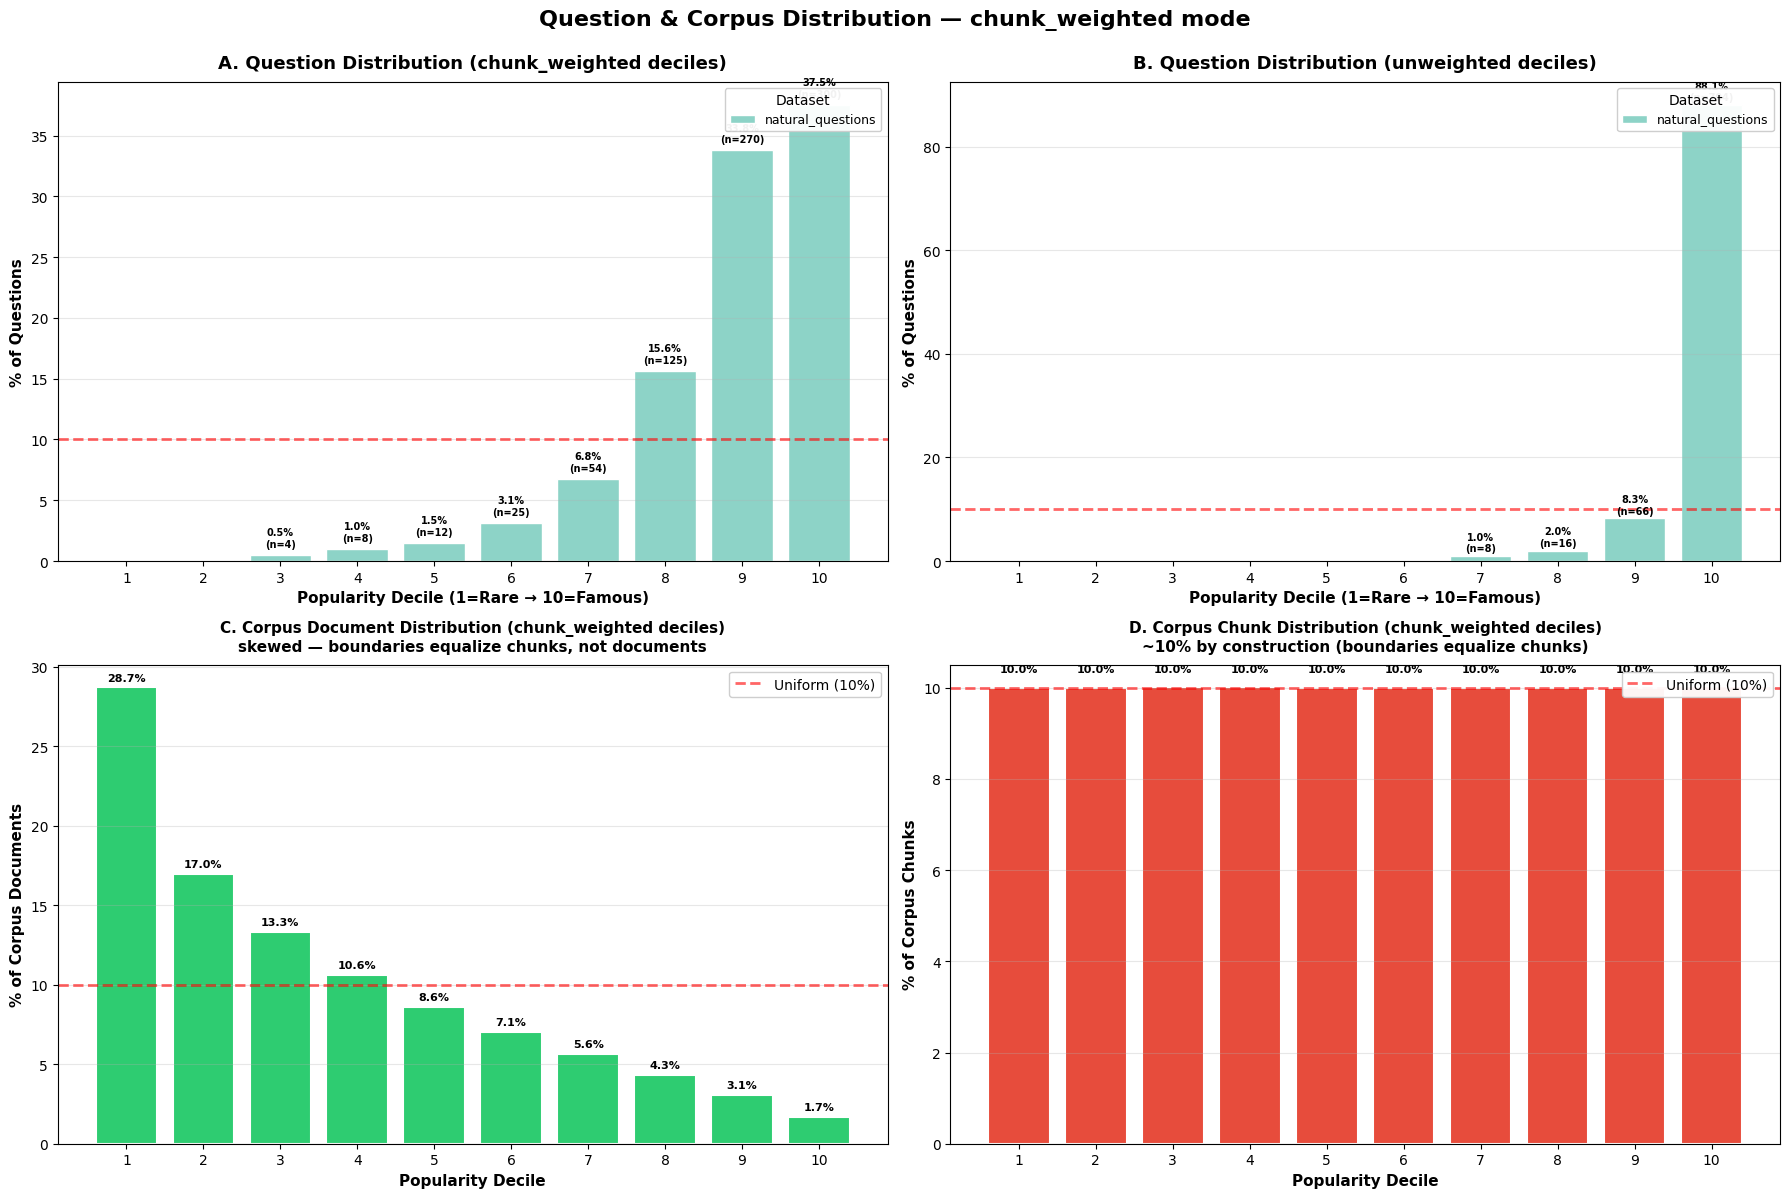

✓ Saved to /Users/cyro/Documents/VSC/PopularityBias/data/wiki_100k_f/nq_300_b/distribution_overview.png


In [4]:
# ============================================================================
# 4. Question & Corpus Distribution — Selected Decile Mode
# ============================================================================

from rag.decile_utils import (
    load_corpus_distributions,
    decile_col_for, boundaries_for,
)

results_df = results_by_strategy[ALL_STRATEGIES[0]]
decile_col = decile_col_for(DECILE_MODE)
boundaries = boundaries_for(DECILE_MODE, boundaries_uw, boundaries_cw)

# --- Load corpus distributions from metadata ---
dists = load_corpus_distributions(corpus_stats, DECILE_MODE)
if dists is None:
    raise RuntimeError(
        "Corpus distributions not found in metadata.json.\n"
        "Run the patching script first:\n"
        f"  python scripts/patch_corpus_distributions.py {RESULTS_DIR}\n"
        "Or re-run rag_retrieval_faiss.ipynb (new runs compute them automatically)."
    )
corpus_docs, corpus_chunks = dists
print(f"✓ Loaded corpus distributions from metadata (mode={DECILE_MODE})")

corpus_doc_pct = (corpus_docs / corpus_docs.sum()) * 100
corpus_chunk_pct = (corpus_chunks / corpus_chunks.sum()) * 100
print(f"  {len(results_df):,} questions, {corpus_docs.sum():,.0f} documents, {corpus_chunks.sum():,.0f} chunks")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- Panel A: Question Distribution (selected mode) ---
ax = axes[0, 0]
if "dataset" in results_df.columns:
    datasets = sorted(results_df["dataset"].dropna().unique())
    bottoms = np.zeros(10)
    colors = plt.cm.Set3.colors
    for i, ds in enumerate(datasets):
        ds_counts = results_df[results_df["dataset"] == ds][decile_col].value_counts().reindex(range(10), fill_value=0)
        ds_pcts = (ds_counts / len(results_df)) * 100
        ax.bar(np.arange(1, 11), ds_pcts.values, bottom=bottoms, color=colors[i % len(colors)],
               edgecolor='white', linewidth=1.0, label=ds)
        bottoms += ds_pcts.values
    for i, total in enumerate(bottoms):
        if total > 0.5:
            count = results_df[decile_col].value_counts().reindex(range(10), fill_value=0).iloc[i]
            ax.text(i + 1, total + 0.5, f'{total:.1f}%\n(n={count})', ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9, framealpha=0.95, title="Dataset")
else:
    q_counts = results_df[decile_col].value_counts().reindex(range(10), fill_value=0)
    q_pcts = (q_counts / len(results_df)) * 100
    ax.bar(np.arange(1, 11), q_pcts.values, color='#3498db', edgecolor='white', linewidth=1.5)
    for i, (val, count) in enumerate(zip(q_pcts.values, q_counts.values)):
        if val > 0.5:
            ax.text(i + 1, val + 0.5, f'{val:.1f}%\n(n={count})', ha='center', va='bottom', fontsize=7)

ax.axhline(10, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Uniform (10%)')
ax.set_xlabel("Popularity Decile (1=Rare → 10=Famous)", fontsize=11, fontweight='bold')
ax.set_ylabel("% of Questions", fontsize=11, fontweight='bold')
ax.set_title(f"A. Question Distribution ({DECILE_MODE} deciles)", fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))

# --- Panel B: Question Distribution (other mode — for comparison) ---
other_mode = "unweighted" if DECILE_MODE == "chunk_weighted" else "chunk_weighted"
other_col = decile_col_for(other_mode)
ax = axes[0, 1]
if "dataset" in results_df.columns:
    datasets = sorted(results_df["dataset"].dropna().unique())
    bottoms = np.zeros(10)
    colors = plt.cm.Set3.colors
    for i, ds in enumerate(datasets):
        ds_counts = results_df[results_df["dataset"] == ds][other_col].value_counts().reindex(range(10), fill_value=0)
        ds_pcts = (ds_counts / len(results_df)) * 100
        ax.bar(np.arange(1, 11), ds_pcts.values, bottom=bottoms, color=colors[i % len(colors)],
               edgecolor='white', linewidth=1.0, label=ds)
        bottoms += ds_pcts.values
    for i, total in enumerate(bottoms):
        if total > 0.5:
            count = results_df[other_col].value_counts().reindex(range(10), fill_value=0).iloc[i]
            ax.text(i + 1, total + 0.5, f'{total:.1f}%\n(n={count})', ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9, framealpha=0.95, title="Dataset")
else:
    q_counts = results_df[other_col].value_counts().reindex(range(10), fill_value=0)
    q_pcts = (q_counts / len(results_df)) * 100
    ax.bar(np.arange(1, 11), q_pcts.values, color='#9b59b6', edgecolor='white', linewidth=1.5)
    for i, (val, count) in enumerate(zip(q_pcts.values, q_counts.values)):
        if val > 0.5:
            ax.text(i + 1, val + 0.5, f'{val:.1f}%\n(n={count})', ha='center', va='bottom', fontsize=7)

ax.axhline(10, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Uniform (10%)')
ax.set_xlabel("Popularity Decile (1=Rare → 10=Famous)", fontsize=11, fontweight='bold')
ax.set_ylabel("% of Questions", fontsize=11, fontweight='bold')
ax.set_title(f"B. Question Distribution ({other_mode} deciles)", fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))

# --- Panel C: Corpus DOCUMENT Distribution ---
ax = axes[1, 0]
bars = ax.bar(np.arange(1, 11), corpus_doc_pct, color='#2ecc71', edgecolor='white', linewidth=1.5)
for i, val in enumerate(corpus_doc_pct):
    if val > 0.5:
        ax.text(i + 1, val + 0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(10, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Uniform (10%)')
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)

if DECILE_MODE == "unweighted":
    c_note = "~10% by construction (boundaries equalize documents)"
else:
    c_note = "skewed — boundaries equalize chunks, not documents"
ax.set_xlabel("Popularity Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("% of Corpus Documents", fontsize=11, fontweight='bold')
ax.set_title(f"C. Corpus Document Distribution ({DECILE_MODE} deciles)\n{c_note}", fontsize=11, fontweight='bold', pad=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))

# --- Panel D: Corpus CHUNK Distribution ---
ax = axes[1, 1]
bars = ax.bar(np.arange(1, 11), corpus_chunk_pct, color='#e74c3c', edgecolor='white', linewidth=1.5)
for i, val in enumerate(corpus_chunk_pct):
    if val > 0.5:
        ax.text(i + 1, val + 0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(10, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Uniform (10%)')
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)

if DECILE_MODE == "chunk_weighted":
    d_note = "~10% by construction (boundaries equalize chunks)"
else:
    d_note = "skewed — boundaries equalize documents, not chunks"
ax.set_xlabel("Popularity Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("% of Corpus Chunks", fontsize=11, fontweight='bold')
ax.set_title(f"D. Corpus Chunk Distribution ({DECILE_MODE} deciles)\n{d_note}", fontsize=11, fontweight='bold', pad=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))

plt.suptitle(f"Question & Corpus Distribution — {DECILE_MODE} mode", fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "distribution_overview.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved to {RESULTS_DIR / 'distribution_overview.png'}")

---

# Part II: Retrieval Performance

Overall retrieval quality across strategies, then broken down by popularity decile.

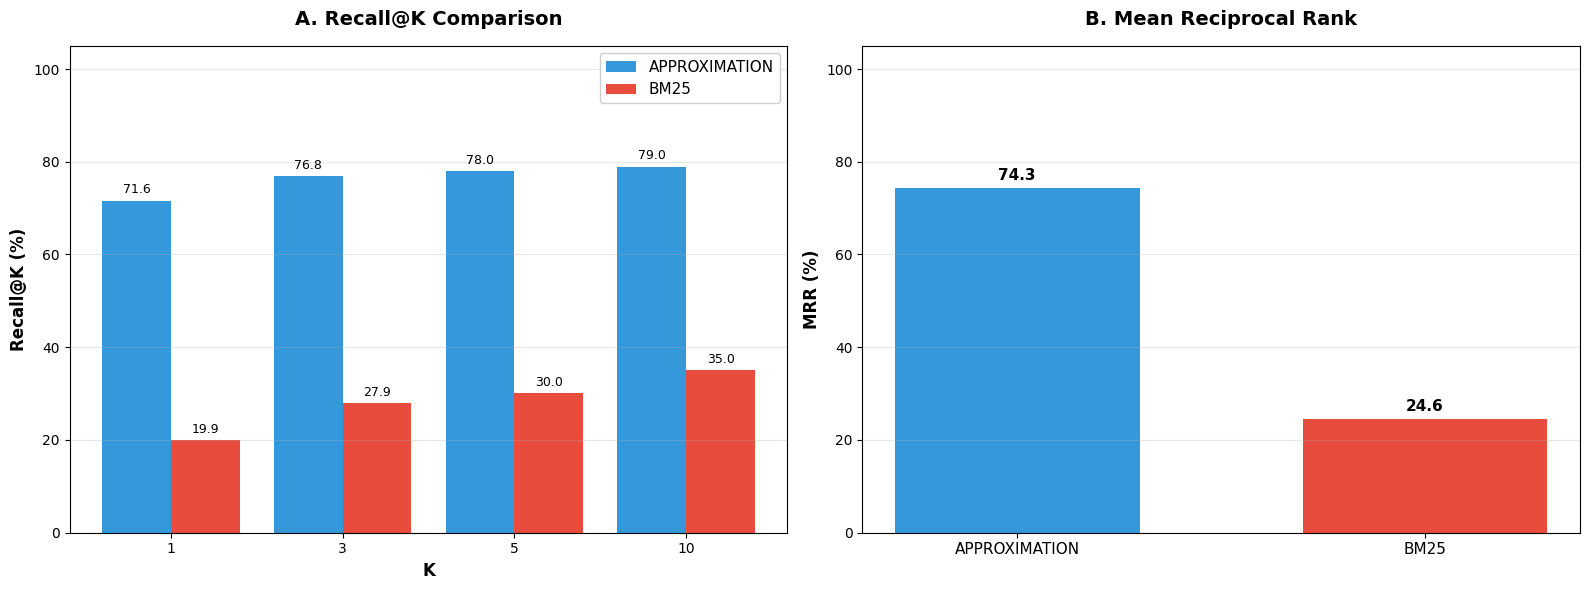

✓ Saved to /Users/cyro/Documents/VSC/PopularityBias/data/wiki_100k_f/nq_300_b/performance_overview.png


In [5]:
# ============================================================================
# 5. Recall@K & MRR Overview
# ============================================================================

strategy_colors = {'approximation': '#3498db', 'vector': '#3498db', 'bm25': '#e74c3c', 'hybrid': '#27ae60'}
markers = {'approximation': 'o', 'vector': 'o', 'bm25': 's', 'hybrid': 'D'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel A: Recall@K Comparison ---
ax = axes[0]
x = np.arange(len(K_VALUES_DETAILED))
width = 0.8 / len(ALL_STRATEGIES)

for i, strategy in enumerate(ALL_STRATEGIES):
    recalls = [metrics_by_strategy[strategy][f"recall@{k}"] for k in K_VALUES_DETAILED]
    color = strategy_colors.get(strategy, plt.cm.tab10.colors[i])
    bars = ax.bar(x + i*width, np.array(recalls) * 100, width, label=strategy.upper(), color=color)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('K', fontsize=12, fontweight='bold')
ax.set_ylabel('Recall@K (%)', fontsize=12, fontweight='bold')
ax.set_title('A. Recall@K Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x + width * (len(ALL_STRATEGIES)-1) / 2)
ax.set_xticklabels(K_VALUES_DETAILED)
ax.legend(fontsize=11, framealpha=0.95)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 105)

# --- Panel B: MRR Comparison ---
ax = axes[1]
mrr_values = [metrics_by_strategy[s]["mrr"] * 100 for s in ALL_STRATEGIES]
colors = [strategy_colors.get(s, plt.cm.tab10.colors[i]) for i, s in enumerate(ALL_STRATEGIES)]
bars = ax.bar(range(len(ALL_STRATEGIES)), mrr_values, color=colors, width=0.6)
for bar, val in zip(bars, mrr_values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('MRR (%)', fontsize=12, fontweight='bold')
ax.set_title('B. Mean Reciprocal Rank', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(range(len(ALL_STRATEGIES)))
ax.set_xticklabels([s.upper() for s in ALL_STRATEGIES], fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "performance_overview.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved to {RESULTS_DIR / 'performance_overview.png'}")

### 6. Performance Across Popularity Deciles

The key question: **does retrieval quality depend on how popular the target entity is?**  
- Left: Recall@K at the primary threshold, split by decile — a flat line means no bias  
- Right: MRR by decile — same story from the ranking perspective

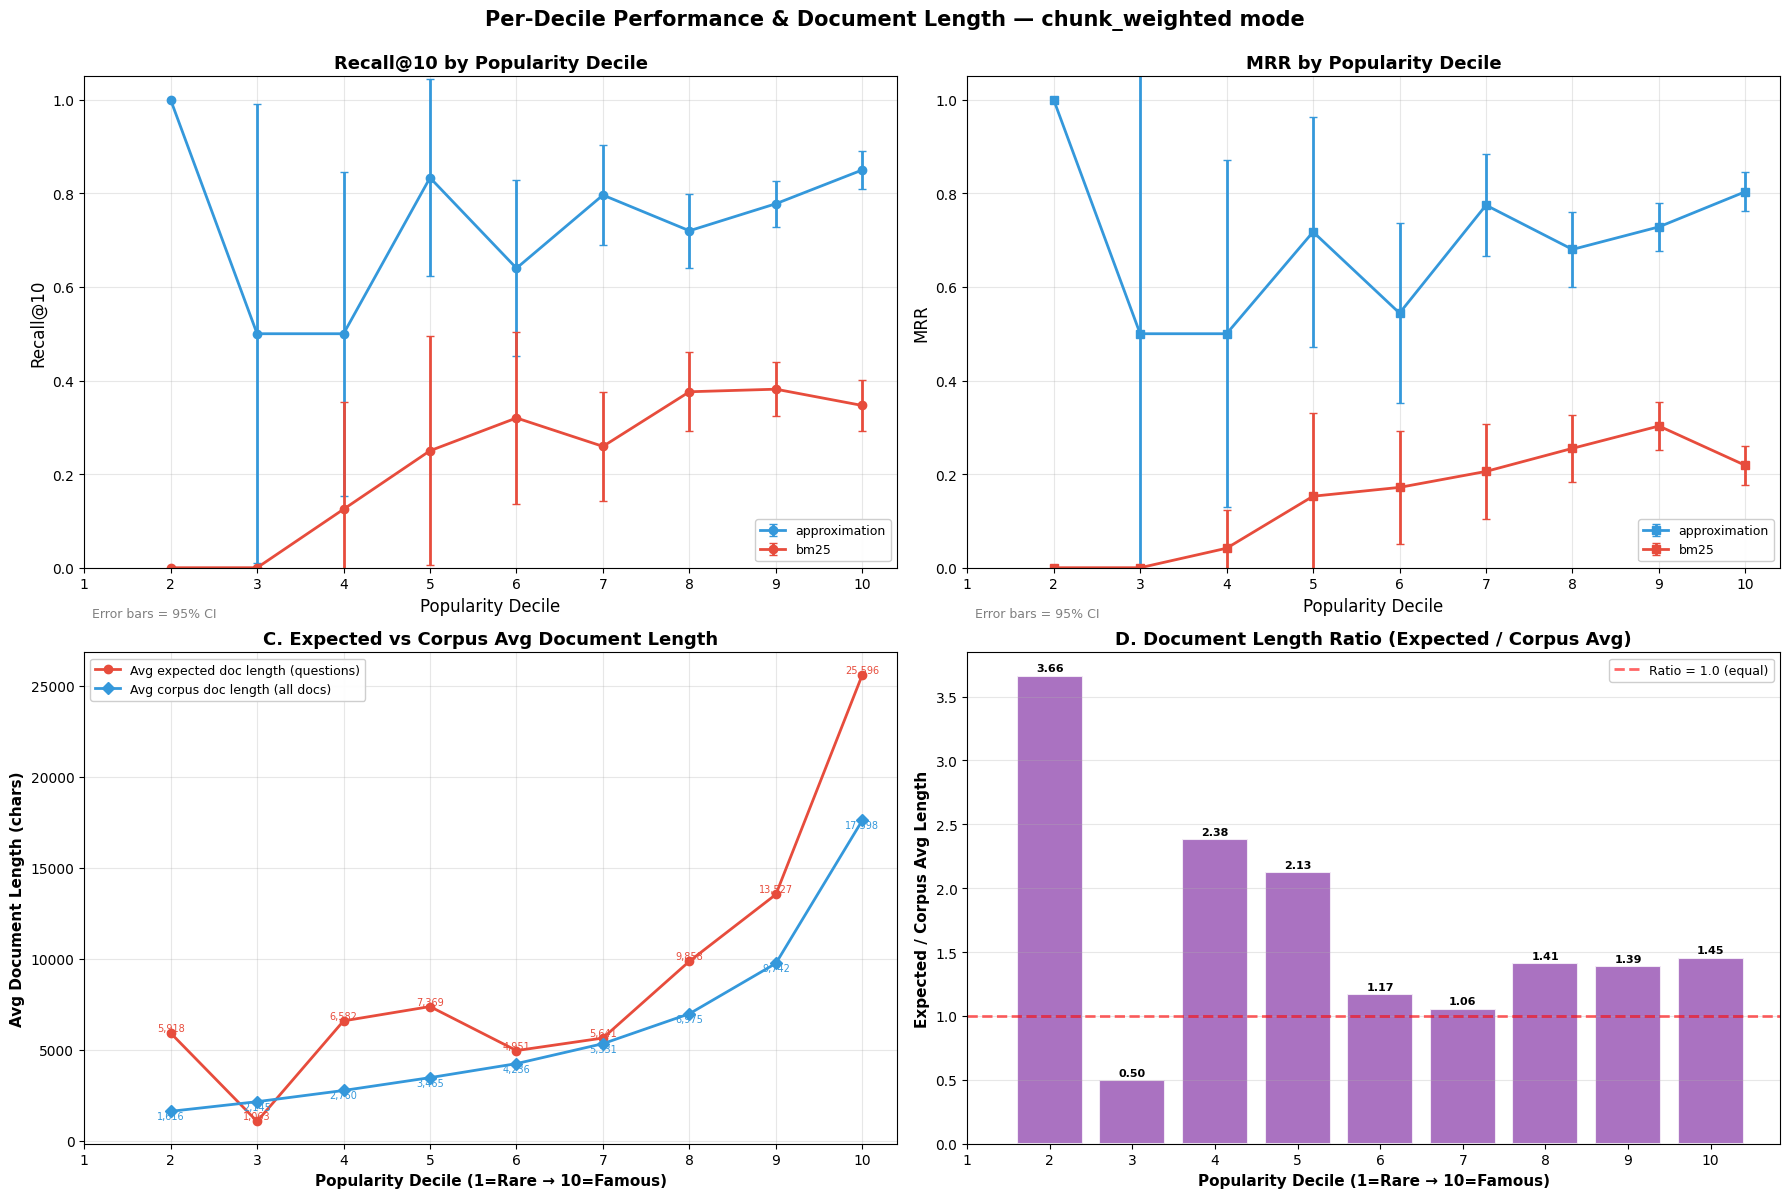

Saved  → per_decile_performance.png


In [6]:
# ============================================================================
# Per-Decile Recall@K  &  MRR  +  Document Length overlays
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

primary_k = K_VALUES_DETAILED[-1]          # e.g. 10
dm0 = decile_metrics_by_strategy[STRATEGIES[0]]

# ---- Panel A: Recall@K per decile (line + 95% CI) -------------------------
ax = axes[0, 0]
for strategy in STRATEGIES:
    dm = decile_metrics_by_strategy[strategy]
    col = f'recall@{primary_k}'
    se_col = f'{col}_se'
    ci_col = f'{col}_ci95'
    if col in dm.columns:
        x = dm['decile'] + 1
        y = dm[col]
        if ci_col in dm.columns:
            yerr = dm[ci_col]
        elif se_col in dm.columns:
            yerr = dm[se_col] * 1.96
        else:
            yerr = np.zeros_like(y)
        ax.errorbar(x, y, yerr=yerr, marker='o', linewidth=2, markersize=6,
                    color=strategy_colors.get(strategy, '#333'),
                    label=f'{strategy}', capsize=3)
ax.set_xlabel('Popularity Decile', fontsize=12)
ax.set_ylabel(f'Recall@{primary_k}', fontsize=12)
ax.set_title(f'Recall@{primary_k} by Popularity Decile', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
ax.text(0.01, -0.10, 'Error bars = 95% CI', transform=ax.transAxes, fontsize=9, color='gray')
ax.legend(fontsize=9, loc='lower right', framealpha=0.95)

# ---- Panel B: MRR per decile (line + 95% CI) ------------------------------
ax = axes[0, 1]
for strategy in STRATEGIES:
    dm = decile_metrics_by_strategy[strategy]
    if 'mrr' in dm.columns:
        x = dm['decile'] + 1
        y = dm['mrr']
        if 'mrr_ci95' in dm.columns:
            yerr = dm['mrr_ci95']
        elif 'mrr_se' in dm.columns:
            yerr = dm['mrr_se'] * 1.96
        else:
            yerr = np.zeros_like(y)
        ax.errorbar(x, y, yerr=yerr, marker='s', linewidth=2, markersize=6,
                    color=strategy_colors.get(strategy, '#333'),
                    label=f'{strategy}', capsize=3)
ax.set_xlabel('Popularity Decile', fontsize=12)
ax.set_ylabel('MRR', fontsize=12)
ax.set_title('MRR by Popularity Decile', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
ax.text(0.01, -0.10, 'Error bars = 95% CI', transform=ax.transAxes, fontsize=9, color='gray')
ax.legend(fontsize=9, loc='lower right', framealpha=0.95)

# ---- Panel C: Avg Document Length — Expected vs Corpus -------------------
ax = axes[1, 0]
x_dec = dm0['decile'] + 1

has_expected = 'avg_expected_doc_length' in dm0.columns and dm0['avg_expected_doc_length'].notna().any()
has_corpus = 'avg_corpus_doc_length' in dm0.columns and dm0['avg_corpus_doc_length'].notna().any()

if has_expected:
    ax.plot(x_dec, dm0['avg_expected_doc_length'], marker='o', linewidth=2, markersize=6,
            color='#e74c3c', label='Avg expected doc length (questions)')
    for xi, yi in zip(x_dec, dm0['avg_expected_doc_length']):
        if not np.isnan(yi):
            ax.text(xi, yi, f'{yi:,.0f}', ha='center', va='bottom', fontsize=7, color='#e74c3c')

if has_corpus:
    ax.plot(x_dec, dm0['avg_corpus_doc_length'], marker='D', linewidth=2, markersize=6,
            color='#3498db', label='Avg corpus doc length (all docs)')
    for xi, yi in zip(x_dec, dm0['avg_corpus_doc_length']):
        if not np.isnan(yi):
            ax.text(xi, yi, f'{yi:,.0f}', ha='center', va='top', fontsize=7, color='#3498db')

ax.set_xlabel('Popularity Decile (1=Rare → 10=Famous)', fontsize=11, fontweight='bold')
ax.set_ylabel('Avg Document Length (chars)', fontsize=11, fontweight='bold')
ax.set_title('C. Expected vs Corpus Avg Document Length', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='best', framealpha=0.95)

# ---- Panel D: Ratio expected / corpus avg doc length ---------------------
ax = axes[1, 1]
has_ratio = 'doc_length_ratio' in dm0.columns and dm0['doc_length_ratio'].notna().any()

if has_ratio:
    ratio_vals = dm0['doc_length_ratio']
    ax.bar(x_dec, ratio_vals, color='#9b59b6', edgecolor='white', linewidth=1.5, alpha=0.85)
    for xi, ri in zip(x_dec, ratio_vals):
        if not np.isnan(ri):
            ax.text(xi, ri + 0.02, f'{ri:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.axhline(1.0, color='red', linestyle='--', linewidth=2, alpha=0.6, label='Ratio = 1.0 (equal)')
    ax.legend(fontsize=9, loc='best', framealpha=0.95)
else:
    ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes, fontsize=12)

ax.set_xlabel('Popularity Decile (1=Rare → 10=Famous)', fontsize=11, fontweight='bold')
ax.set_ylabel('Expected / Corpus Avg Length', fontsize=11, fontweight='bold')
ax.set_title('D. Document Length Ratio (Expected / Corpus Avg)', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Per-Decile Performance & Document Length — {DECILE_MODE} mode',
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(str(RESULTS_DIR), 'per_decile_performance.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved  → per_decile_performance.png")

### 6b. Performance vs ln(Popularity) — Point Cloud

Instead of aggregating into deciles, plot **every question** as a single point:
- **x-axis**: $\ln(\text{popularity})$ (continuous scale)
- **y-axis**: Recall@K (binary: 0 or 1) or Reciprocal Rank
- **colour**: dataset of origin
- **fit curve**: binned mean with 95% CI band to reveal the underlying trend

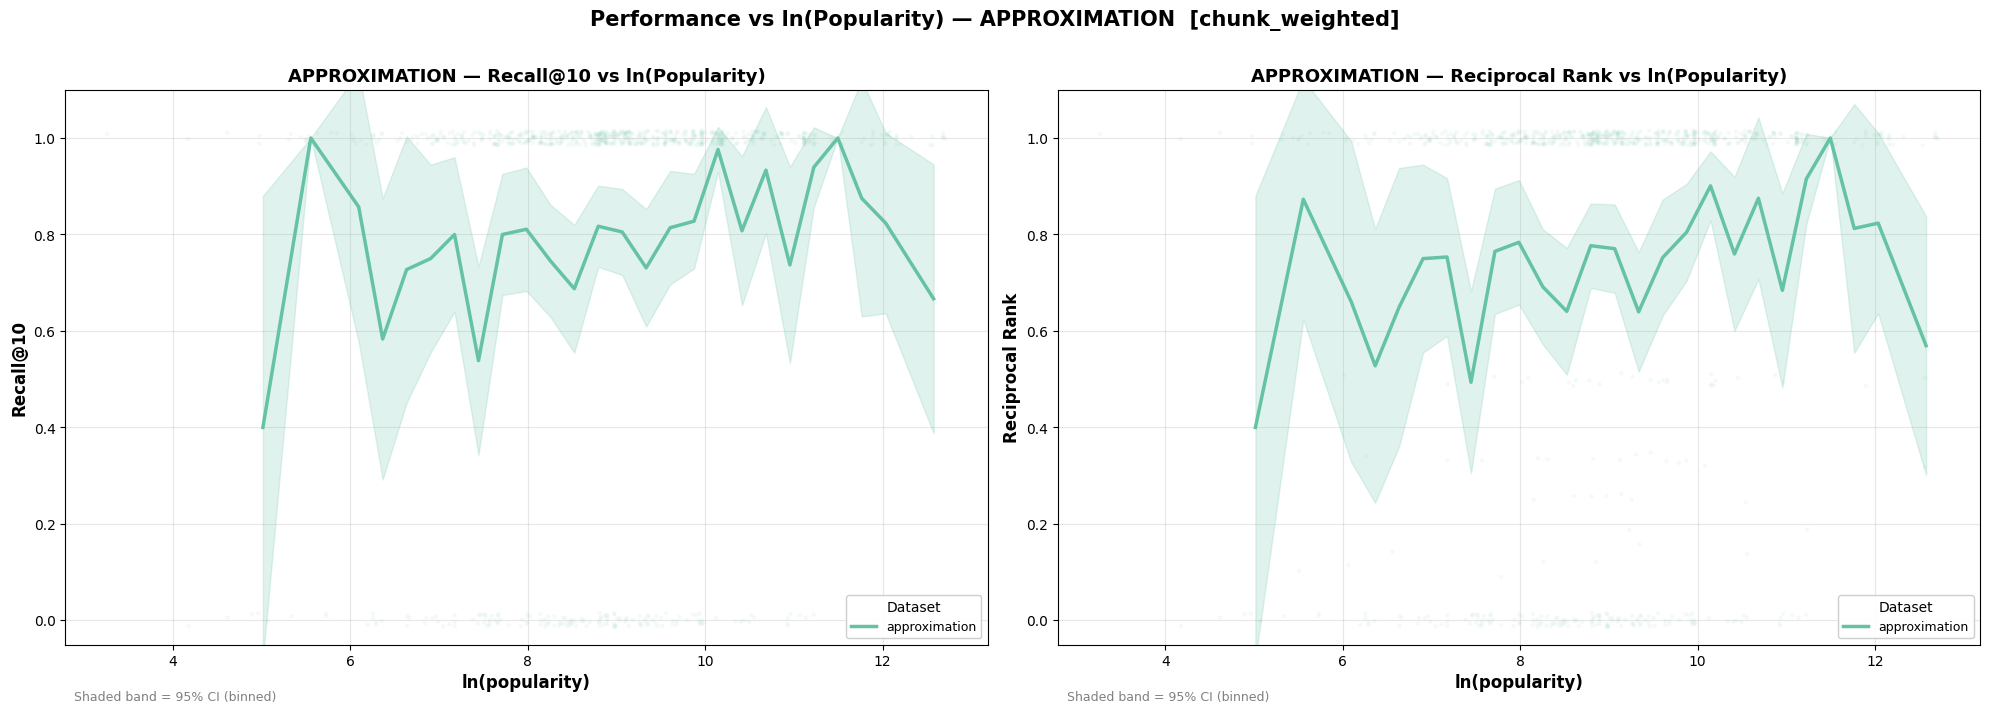

Saved → pointcloud_performance_approximation.png


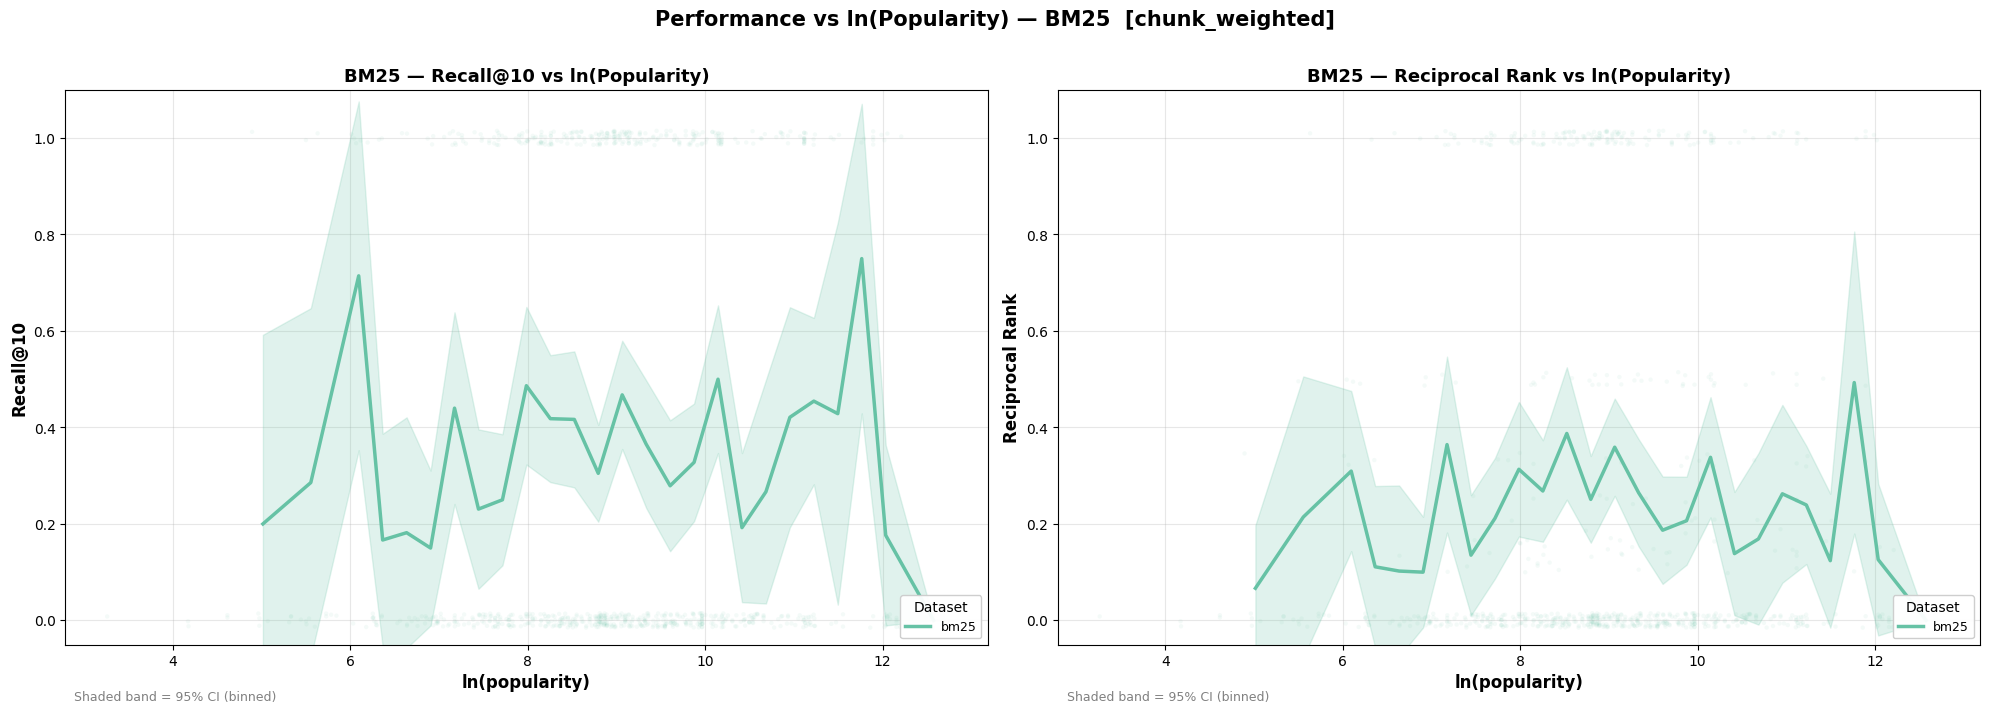

Saved → pointcloud_performance_bm25.png


In [7]:
# ============================================================================
# 6b. Point Cloud: Recall / MRR vs ln(Popularity), coloured by dataset
# ============================================================================

primary_k = K_VALUES_DETAILED[-1]
recall_col = f"recall@{primary_k}"

def _binned_stats(x_vals, y_vals, n_bins=35, min_pts=5):
    """Return bin centers, means and 95% CI half-widths."""
    bins = np.linspace(x_vals.min(), x_vals.max(), n_bins + 1)
    centers, means, ci = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (x_vals >= lo) & (x_vals <= hi)
        n = mask.sum()
        if n < min_pts:
            continue
        y = y_vals[mask]
        m = y.mean()
        se = y.std(ddof=1) / np.sqrt(n) if n > 1 else 0.0
        centers.append((lo + hi) / 2)
        means.append(m)
        ci.append(1.96 * se)
    return np.array(centers), np.array(means), np.array(ci)


def _plot_panel(ax, df, metric_col, datasets, palette, has_dataset, title, ylabel):
    rng = np.random.default_rng(42)
    for ds in datasets:
        sub = df[df["dataset"] == ds].copy() if has_dataset else df.copy()
        colour = palette[ds]
        x = sub["ln_popularity"].values
        y = sub[metric_col].values

        jitter = rng.uniform(-0.015, 0.015, size=len(y))
        ax.scatter(x, np.clip(y + jitter, -0.05, 1.05),
                   alpha=0.07, s=10, color=colour, edgecolors="none", zorder=1)

        if len(sub) > 30:
            fx, fy, fci = _binned_stats(x, y)
            if len(fx) > 2:
                ax.plot(fx, fy, linewidth=2.5, color=colour, label=ds, zorder=3)
                ax.fill_between(fx, fy - fci, fy + fci,
                                color=colour, alpha=0.20, zorder=2)

    ax.set_xlabel("ln(popularity)", fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylim(-0.05, 1.10)
    ax.legend(title="Dataset", fontsize=9, framealpha=0.95, loc="lower right")
    ax.text(0.01, -0.10, "Shaded band = 95% CI (binned)", transform=ax.transAxes,
            fontsize=9, color="gray")
    ax.grid(True, alpha=0.3)


for strategy in STRATEGIES:
    df = results_by_strategy[strategy].copy()
    df = df[df[COL_POPULARITY] > 0].copy()
    df["ln_popularity"] = np.log(df[COL_POPULARITY])

    has_dataset = "dataset" in df.columns and df["dataset"].nunique() > 1
    datasets = sorted(df["dataset"].dropna().unique()) if has_dataset else [strategy]
    palette = dict(zip(datasets, sns.color_palette("Set2", len(datasets))))

    fig, axes = plt.subplots(1, 2, figsize=(20, 7))

    _plot_panel(axes[0], df, recall_col, datasets, palette, has_dataset,
                f"{strategy.upper()} — Recall@{primary_k} vs ln(Popularity)",
                f"Recall@{primary_k}")

    _plot_panel(axes[1], df, "reciprocal_rank", datasets, palette, has_dataset,
                f"{strategy.upper()} — Reciprocal Rank vs ln(Popularity)",
                "Reciprocal Rank")

    plt.suptitle(f"Performance vs ln(Popularity) — {strategy.upper()}  [{DECILE_MODE}]",
                 fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"pointcloud_performance_{strategy}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → pointcloud_performance_{strategy}.png")

## Distance to Query Vector — Per-Decile Analysis

Standard formulas:

- similarity s in [0,1]  → distance = 1 - s
- positive retrieval score x (e.g. BM25)  → inverse distance = 1 / (1 + x)
- generic fallback (preserves ordering): distance = 1 / (1 + max(0, x))

✓ Saved distance_topk_per_decile.csv
✓ Saved bm25_topk_score_per_decile.csv


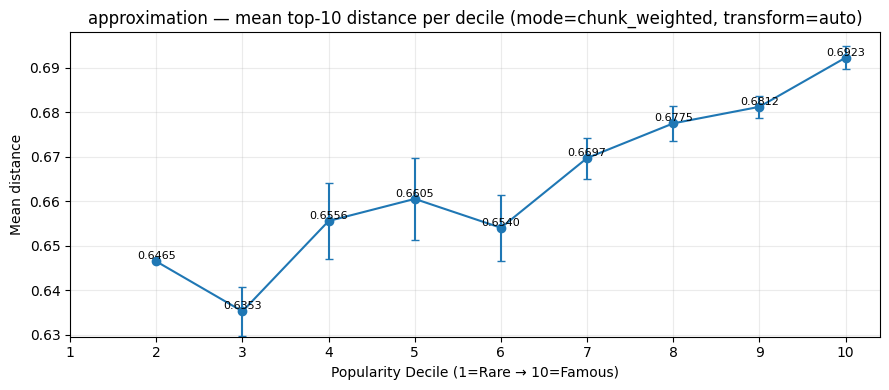

Saved → distance_topk_approximation.png


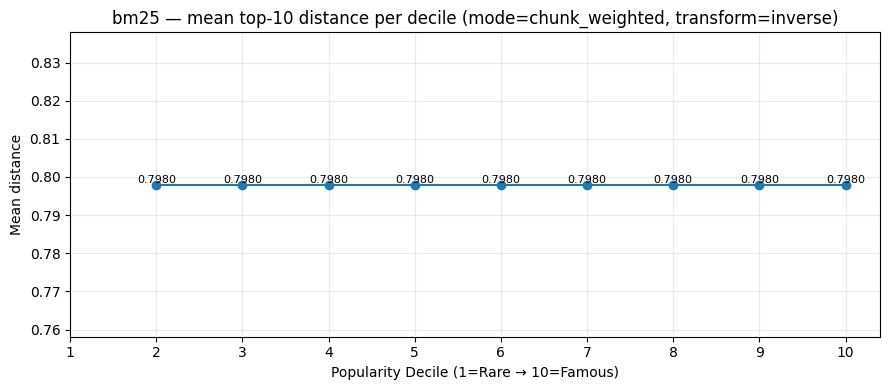

Saved → distance_topk_bm25.png


In [8]:
# ---------------------------------------------------------------------------
# Simplified & configurable Top-K distance / score analysis
# ---------------------------------------------------------------------------
import ast
from rag.decile_utils import decile_col_for

decile_col = decile_col_for(DECILE_MODE)

TRANSFORMS = {
    'approximation': 'auto',
    'bm25': 'inverse',
}

def apply_transform(strategy: str, value):
    try:
        v = float(value)
    except Exception:
        return np.nan
    mode = TRANSFORMS.get(strategy, 'auto')
    if mode == 'similarity':
        return 1.0 - v
    if mode == 'inverse':
        return 1.0 / (1.0 + v)
    if 0.0 <= v <= 1.0:
        return 1.0 - v
    return 1.0 / (1.0 + v) if v >= 0 else np.nan

# --- Vectorized per-question distance aggregation ---
rows = []
for strategy, df in results_by_strategy.items():
    dec_vals = df[decile_col].values
    score_lists = df['topk_scores'].values

    for idx in range(len(df)):
        dec = dec_vals[idx]
        if dec is None or (isinstance(dec, float) and np.isnan(dec)):
            continue

        raw_scores = score_lists[idx]
        if raw_scores is None:
            continue
        if isinstance(raw_scores, str):
            try:
                raw_scores = ast.literal_eval(raw_scores)
            except Exception:
                continue

        scores_list = [s for s in list(raw_scores)[:TOP_K] if s is not None]
        if not scores_list:
            continue

        dlist = [apply_transform(strategy, s) for s in scores_list]
        mean_dist = float(np.nanmean(dlist))

        raw_mean = np.nan
        if strategy == 'bm25':
            raw_vals = [float(s) for s in scores_list if s is not None]
            raw_mean = float(np.nanmean(raw_vals)) if raw_vals else np.nan

        rows.append({
            'strategy': strategy,
            decile_col: int(dec),
            'mean_topk_distance': mean_dist,
            'mean_topk_score': raw_mean,
            'n_in_topk': len(scores_list),
        })

exp_df = pd.DataFrame(rows)
if exp_df.empty:
    print('No top-k scores found — check `topk_scores`.')
else:
    dist_rows = exp_df[exp_df['mean_topk_distance'].notna()].copy()
    if not dist_rows.empty:
        agg_dist = dist_rows.groupby(['strategy', decile_col]).mean_topk_distance.agg(['mean', 'count', 'std']).reset_index()
        agg_dist['sem'] = agg_dist.apply(lambda r: (r['std'] / np.sqrt(r['count'])) if r['count'] > 0 else np.nan, axis=1)
        agg_dist = agg_dist.rename(columns={'mean': 'mean_distance'}).sort_values(['strategy', decile_col]).reset_index(drop=True)
        (RESULTS_DIR / 'distance_topk_per_decile.csv').write_text(agg_dist.to_csv(index=False))
        print(f'✓ Saved distance_topk_per_decile.csv')
    else:
        agg_dist = pd.DataFrame()

    score_rows = exp_df[exp_df['mean_topk_score'].notna()].copy()
    if not score_rows.empty:
        agg_score = score_rows.groupby(['strategy', decile_col]).mean_topk_score.agg(['mean','count','std']).reset_index()
        agg_score['sem'] = agg_score.apply(lambda r: (r['std'] / np.sqrt(r['count'])) if r['count'] > 0 else np.nan, axis=1)
        agg_score = agg_score.rename(columns={'mean': 'mean_score'}).sort_values(['strategy', decile_col]).reset_index(drop=True)
        (RESULTS_DIR / 'bm25_topk_score_per_decile.csv').write_text(agg_score.to_csv(index=False))
        print(f'✓ Saved bm25_topk_score_per_decile.csv')
    else:
        agg_score = pd.DataFrame()

    if not agg_dist.empty:
        for strat in agg_dist['strategy'].unique():
            sub = agg_dist[agg_dist['strategy'] == strat].set_index(decile_col).reindex(range(10))
            x = (sub.index + 1).values
            y = sub['mean_distance'].values
            yerr = sub['sem'].values

            plt.figure(figsize=(9,4))
            plt.errorbar(x, y, yerr=yerr, marker='o', linestyle='-', capsize=3)
            valid = sub['mean_distance'].dropna().values
            if len(valid) > 0:
                span = float(np.ptp(valid)) if float(np.ptp(valid))>0 else 1e-6
                ymin = max(0.0, float(valid.min()) - 0.10 * span)
                ymax = min(1.0, float(valid.max()) + 0.10 * span)
                if ymin < ymax:
                    plt.ylim(ymin, ymax)
            plt.title(f"{strat} — mean top-{TOP_K} distance per decile (mode={DECILE_MODE}, transform={TRANSFORMS.get(strat,'auto')})")
            plt.xticks(range(1,11))
            plt.xlabel('Popularity Decile (1=Rare → 10=Famous)')
            plt.ylabel('Mean distance')
            plt.grid(alpha=0.25)
            for xi, yi in zip(x, y):
                if not np.isnan(yi):
                    plt.text(xi, yi, f"{yi:.4f}", ha='center', va='bottom', fontsize=8)
            out_plot = RESULTS_DIR / f'distance_topk_{strat}.png'
            plt.tight_layout(); plt.savefig(out_plot, dpi=150, bbox_inches='tight'); plt.show()
            print(f"Saved → {out_plot.name}")

# Part III: Fairness & Popularity Bias Analysis

Now that we know *how well* each strategy retrieves, we investigate *how fairly* it retrieves.

- **Expected vs. Retrieved popularity**: do retrieved documents come from the same popularity tier as the question target?
- **Popularity preference**: when the system retrieves the wrong document, is that document *more popular* than the correct one?
- **Where do wrong documents come from?** — per-decile origin analysis

### 7. Expected vs. Retrieved Popularity Heatmap

Each cell $(i, j)$ shows the fraction of questions whose target is in popularity decile $i$ but whose **top-1 retrieved document** falls into corpus-popularity decile $j$.  
A perfectly unbiased system concentrates mass on the diagonal (green squares).

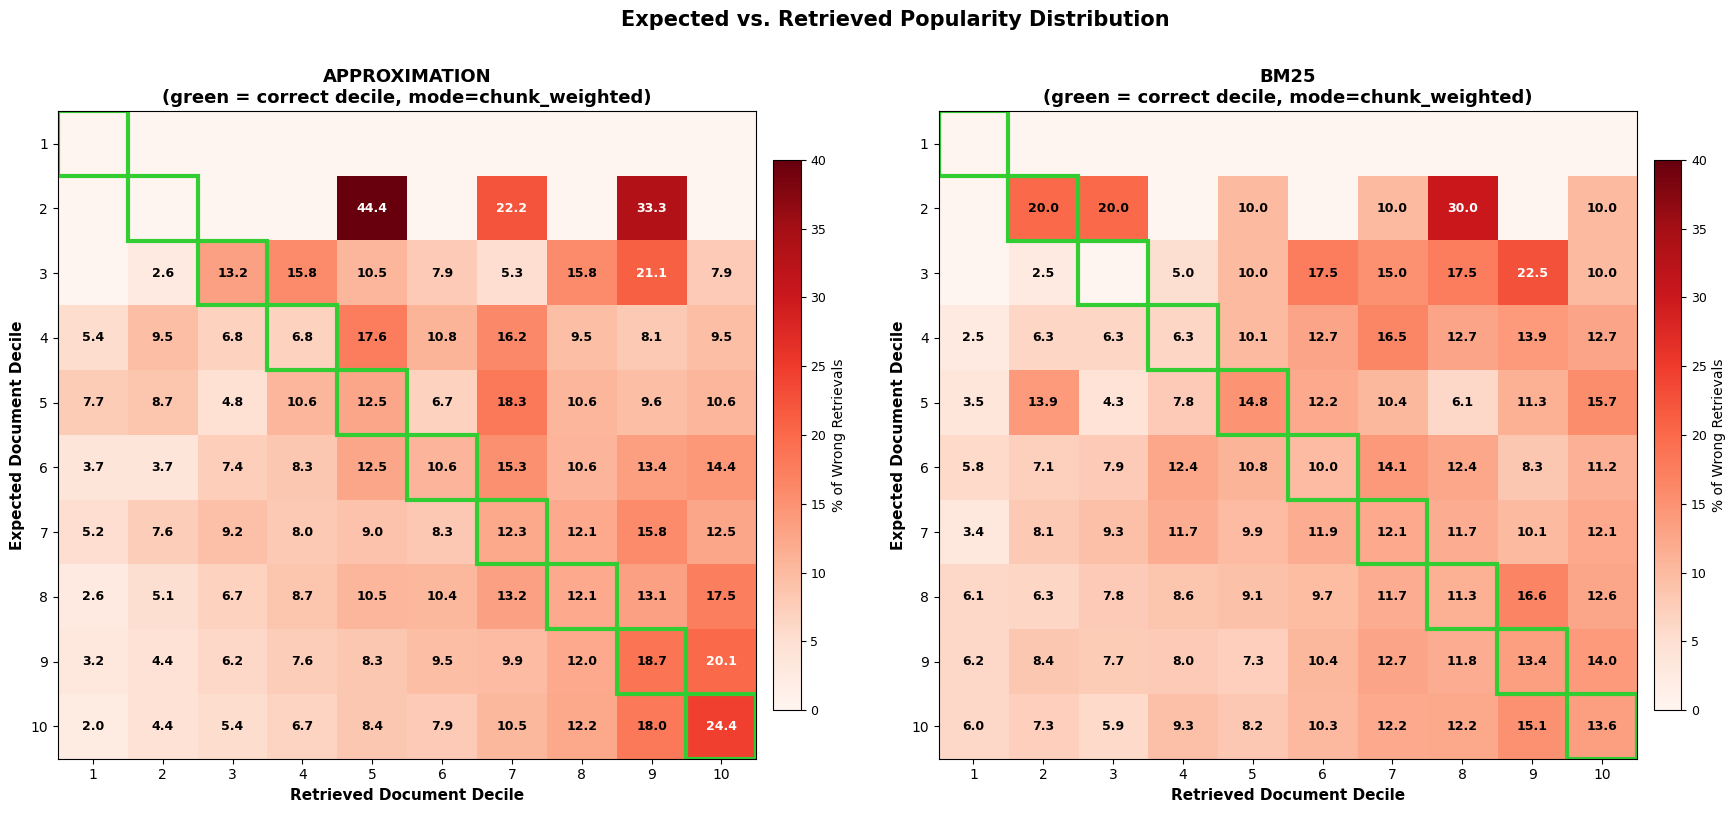

Saved  → expected_vs_retrieved_heatmap.png


In [9]:
# ============================================================================
# Expected vs Retrieved Popularity Heatmap
# ============================================================================

from rag.decile_utils import decile_col_for, boundaries_for

decile_col = decile_col_for(DECILE_MODE)
boundaries = boundaries_for(DECILE_MODE, boundaries_uw, boundaries_cw)

n_strats = len(STRATEGIES)
fig, axes = plt.subplots(1, n_strats, figsize=(9 * n_strats, 8))
if n_strats == 1:
    axes = [axes]

for ax, strategy in zip(axes, STRATEGIES):
    df = results_by_strategy[strategy]

    hm = np.zeros((10, 10))
    for _, row in df.iterrows():
        expected_dec = int(row[decile_col])
        wrong_pops = row['wrong_docs_popularities']
        if wrong_pops is not None and len(wrong_pops) > 0:
            for wp in wrong_pops:
                wd = int(assign_decile(wp, boundaries))
                hm[expected_dec, wd] += 1

    row_sums = hm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    hm_pct = hm / row_sums * 100

    im = ax.imshow(hm_pct, aspect='auto', cmap='Reds', vmin=0, vmax=40)
    cbar = plt.colorbar(im, ax=ax, label='% of Wrong Retrievals', pad=0.02, shrink=0.85)
    cbar.ax.tick_params(labelsize=9)

    for i in range(10):
        for j in range(10):
            if hm_pct[i, j] > 1:
                colour = 'white' if hm_pct[i, j] > 20 else 'black'
                ax.text(j, i, f'{hm_pct[i, j]:.1f}', ha='center', va='center',
                        color=colour, fontsize=9, fontweight='bold')

    for i in range(10):
        ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1,
                                   fill=False, edgecolor='limegreen', linewidth=3))

    ax.set_xticks(range(10));  ax.set_xticklabels(range(1, 11))
    ax.set_yticks(range(10));  ax.set_yticklabels(range(1, 11))
    ax.set_xlabel('Retrieved Document Decile', fontsize=11, fontweight='bold')
    ax.set_ylabel('Expected Document Decile', fontsize=11, fontweight='bold')
    ax.set_title(f'{strategy.upper()}\n(green = correct decile, mode={DECILE_MODE})', 
                 fontsize=13, fontweight='bold')

plt.suptitle('Expected vs. Retrieved Popularity Distribution', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(str(RESULTS_DIR), 'expected_vs_retrieved_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved  → expected_vs_retrieved_heatmap.png")

### 8. Popularity Preference Curve

For each expected-popularity decile: when the system retrieves a **wrong** document, how often is that document **more popular** than the correct answer?

$$P(\text{wrong} > \text{expected}) = \frac{\#\{\text{wrong docs with pop} > \text{target pop}\}}{\#\{\text{all wrong docs}\}}$$

Values above 0.5 indicate a systematic preference for popular content.

ValueError: No valid wrong popularity data for strategy 'approximation' in decile 0

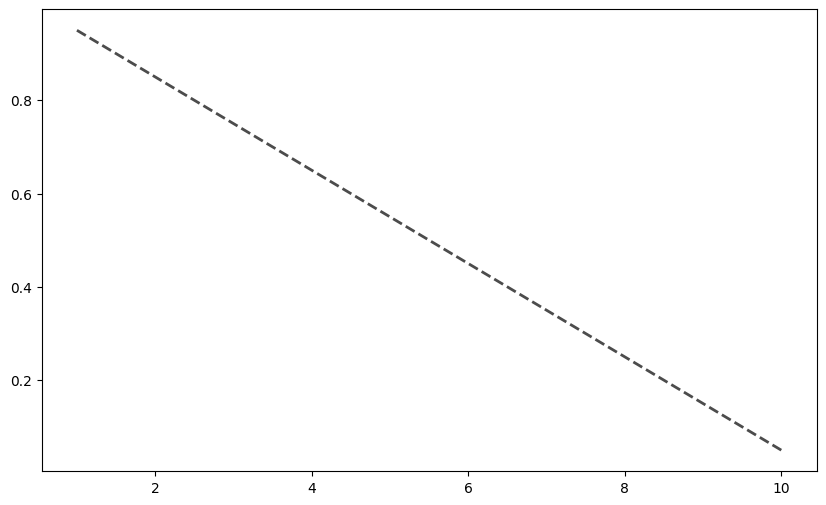

In [10]:
# ============================================================================
# Popularity Preference  (one line per strategy)
# ============================================================================

from rag.decile_utils import decile_col_for

decile_col = decile_col_for(DECILE_MODE)

fig, ax = plt.subplots(figsize=(10, 6))

expected_random = [(10 - d) / 10 - 0.05 for d in range(10)]
ax.plot(range(1, 11), expected_random, '--', color='black', linewidth=2, label='Expected (Random)', alpha=0.7)

for strategy in STRATEGIES:
    df = results_by_strategy[strategy]
    bias_per_decile = []
    bias_se_per_decile = []

    for d in range(10):
        subset = df[df[decile_col] == d]
        n_higher, n_total = 0, 0

        for wp_list, pop in zip(subset['wrong_docs_popularities'], subset[COL_POPULARITY]):
            if wp_list is None or len(wp_list) == 0 or pop is None:
                continue
            for wp in wp_list:
                n_total += 1
                if wp > pop:
                    n_higher += 1

        if n_total > 0:
            p = n_higher / n_total
            se = np.sqrt(p * (1 - p) / n_total)
            ci95 = 1.96 * se
        else:
            raise ValueError(f"No valid wrong popularity data for strategy '{strategy}' in decile {d}")

        bias_per_decile.append(p)
        bias_se_per_decile.append(ci95)

    ax.errorbar(range(1, 11), bias_per_decile, yerr=bias_se_per_decile, marker='o', linewidth=2.5, markersize=8,
                color=strategy_colors.get(strategy, '#333'), label=strategy,
                markeredgewidth=1.5, markeredgecolor='white', capsize=3)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=2, alpha=0.6, label='Random (50 %)')
ax.fill_between(range(1, 11), [0.5]*10, bias_per_decile, alpha=0.15,
                color=strategy_colors.get(STRATEGIES[-1], '#ccc'))

ax.set_xlabel(f'Expected Popularity Decile ({DECILE_MODE})', fontsize=12, fontweight='bold')
ax.set_ylabel('P(Wrong Doc More Popular)', fontsize=12, fontweight='bold')
ax.set_title('Popularity Preference of Wrong Retrievals', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, framealpha=0.95)
ax.text(0.01, -0.12, 'Error bars = 95% CI', transform=ax.transAxes, fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(os.path.join(str(RESULTS_DIR), 'popularity_preference.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved  → popularity_preference.png")

### 9. Per-Decile Wrong Retrieval Origins

For each expected-popularity decile, where do the **wrongly retrieved** documents come from?  
Each subplot is one expected decile; bars show the popularity distribution of wrong retrievals.  
The green-bordered bar marks the "same decile" — ideally the tallest bar.

In [ ]:
# ============================================================================
# Per-Decile Wrong Retrieval Origins  (2×5 grid, one subplot per decile)
# ============================================================================

from rag.decile_utils import decile_col_for, boundaries_for

decile_col = decile_col_for(DECILE_MODE)
boundaries = boundaries_for(DECILE_MODE, boundaries_uw, boundaries_cw)

for strategy in STRATEGIES:
    df = results_by_strategy[strategy]

    hm = np.zeros((10, 10))
    for _, row in df.iterrows():
        expected_dec = int(row[decile_col])
        wrong_pops = row['wrong_docs_popularities']
        if wrong_pops is not None and len(wrong_pops) > 0:
            for wp in wrong_pops:
                wd = int(assign_decile(wp, boundaries))
                hm[expected_dec, wd] += 1

    row_sums = hm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    hm_pct = hm / row_sums * 100

    fig, axes = plt.subplots(2, 5, figsize=(24, 10), sharey=True)
    axes_flat = axes.flatten()
    cmap = plt.cm.Reds
    norm = plt.Normalize(vmin=0, vmax=hm_pct.max())

    for decile in range(10):
        ax = axes_flat[decile]
        values = hm_pct[decile]
        colors = [cmap(norm(v)) for v in values]

        bars = ax.bar(np.arange(1, 11), values, color=colors, edgecolor='white', linewidth=1.2)

        bars[decile].set_edgecolor('limegreen')
        bars[decile].set_linewidth(3)

        for i, val in enumerate(values):
            if val > 2:
                ax.text(i + 1, val + 0.8, f'{val:.1f}%', ha='center', va='bottom',
                        fontsize=8, fontweight='bold')

        ax.set_title(f'Decile {decile + 1}', fontsize=13, fontweight='bold')
        ax.set_xticks(range(1, 11))
        ax.set_xticklabels(range(1, 11), fontsize=8)
        ax.set_ylim(0, hm_pct.max() * 1.25)
        ax.grid(axis='y', alpha=0.3)

        if decile % 5 == 0:
            ax.set_ylabel('% of Wrong Retrievals', fontsize=10, fontweight='bold')
        if decile >= 5:
            ax.set_xlabel('Retrieved Doc Decile', fontsize=9)

    fig.suptitle(
        f'Wrong Retrieval Origins per Expected Decile — {strategy.upper()}\n'
        f'(green-bordered bar = same decile, mode={DECILE_MODE})',
        fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(str(RESULTS_DIR), f'wrong_retrieval_origins_{strategy}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved  → wrong_retrieval_origins_{strategy}.png")

# Part IV: Export & Summary

Save per-decile metrics and key findings for downstream use.

In [ ]:
# ============================================================================
# Save per-decile CSVs  &  print key findings
# ============================================================================

for strategy in STRATEGIES:
    dm = decile_metrics_by_strategy[strategy]
    path = os.path.join(str(RESULTS_DIR), f'per_decile_{strategy}.csv')
    dm.to_csv(path, index=False)
    print(f"Saved  → {path}")

# ---------- Aggregate metrics comparison table ----------
rows = []
for strategy in STRATEGIES:
    metrics = metrics_by_strategy[strategy]
    
    row = {'strategy': strategy}
    for k in K_VALUES_DETAILED:
        row[f'recall@{k}'] = (metrics[f'recall@{k}'] * 100).round(2)
    row['mrr'] = (metrics['mrr']).round(4)
    row['median_rank'] = metrics.get('median_rank')
    rows.append(row)

comparison = pd.DataFrame(rows)
comp_path = os.path.join(str(RESULTS_DIR), 'metrics_comparison.csv')
comparison.to_csv(comp_path, index=False)
print(f"Saved  → {comp_path}")
print()
display(comparison)